<a href="https://colab.research.google.com/github/nomanabdullah04/MaChineLearning/blob/MachineLearning/LOF_anomaly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Local Outlier Factor (LOF)

---


> **Purpose:** Reference guide for understanding local density-based anomaly detection.

## 1. The Core Philosophy: Global vs. Local Anomalies

Most traditional anomaly detection algorithms use a **global perspective**. They assume that normal data forms tight clusters, and any point far away from the center of those clusters is an outlier. However, this logic breaks down completely when a dataset contains clusters with **different densities**.

**Local Outlier Factor (LOF)** solves this by evaluating a data point not against the entire dataset, but **strictly relative to its immediate local neighborhood**.

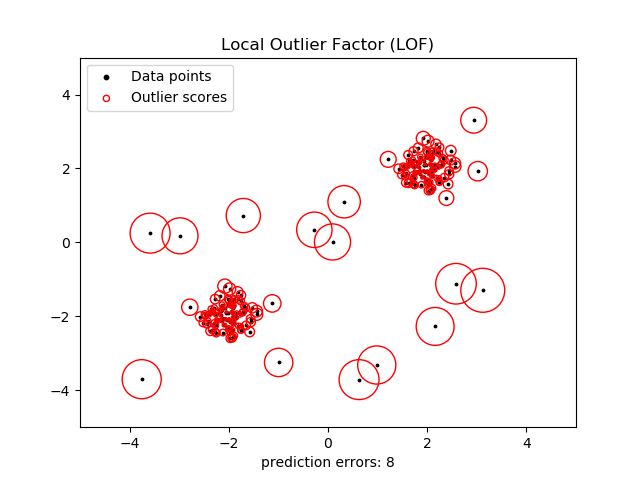

## 2. The Real-World Analogy: City vs. Suburbs

Imagine a single city that contains two distinct residential zones:
* **The Downtown High-Rise District:** Apartment buildings are packed tightly together. The normal distance between two front doors is only **10 meters**.
* **The Suburban Estate District:** Large mansions are spread far apart. The normal distance between two front doors is **300 meters**.

### The Failure of Global Rules
If a global algorithm applies a blanket rule stating: *"Any house located more than 50 meters away from its nearest neighbor is an anomaly,"* it will fail catastrophically:
1. It will accidentally classify **every normal mansion in the suburbs** as an anomaly.
2. It will completely fail to detect an apartment building in Downtown that is **40 meters away** from its neighbors, even though a 40-meter gap is highly abnormal for a crowded downtown core.

### The LOF Solution
LOF dynamically scales its expectations based on the local neighborhood:
* **In Downtown:** It notices that neighbors are usually 10m apart. If it finds a house 40m away, it calculates a **high anomaly score**.
* **In the Suburbs:** It notices that neighbors are normally 300m apart. If it finds a house 300m away, it calculates a **normal score**.


## 3. Step-by-Step Mathematical Mechanics

LOF determines how anomalous a target point $p$ is by executing a four-step local density calculation.

### Step 1: Define the $k$-Neighborhood
The user selects a value $k$ (the number of neighbors to check). The algorithm calculates the Euclidean distance from a target point $p$ to its $k$-th nearest neighbor. This distance is called the **$k$-distance of $p$**.

Every point sitting inside this radius belongs to the local neighborhood:
$$N_k(p) = \{ q \in X \mid d(p, q) \le k\text{-distance}(p) \}$$

### Step 2: Calculate Reachability Distance
To prevent tiny, accidental spacing variations from breaking the math when points are packed incredibly close together, LOF introduces a smoothing metric called **Reachability Distance**:
$$\text{reach-dist}_k(p, o) = \max \left\{ k\text{-distance}(o), \, d(p, o) \right\}$$

* If point $p$ is far away from neighbor $o$, it uses the true distance $d(p,o)$.
* If point $p$ is very close to neighbor $o$, it replaces the true distance with $o$'s own neighborhood radius.

### Step 3: Compute Local Reachability Density (LRD)
The local reachability density of point $p$ is the inverse of the average reachability distance from its neighbors. It represents how tightly packed the points are inside $p$'s local bubble:
$$\text{lrd}_k(p) = \frac{\lvert N_k(p) \rvert}{\sum_{o \in N_k(p)} \text{reach-dist}_k(p, o)}$$

* **High LRD:** The neighbors are very close; local density is high.
* **Low LRD:** The neighbors are far apart; local density is low.

### Step 4: Compute the Final LOF Score
Finally, the algorithm compares the density of point $p$ against the densities of its neighbors. It calculates the average ratio of the neighbors' LRD to $p$'s LRD:
$$\text{LOF}_k(p) = \frac{\sum_{o \in N_k(p)} \frac{\text{lrd}_k(o)}{\text{lrd}_k(p)}}{\lvert N_k(p) \rvert}$$

## 4. How to Interpret the Continuous LOF Score

Unlike binary models that give a rigid "yes" or "no", LOF provides a continuous numerical factor for every data instance:

| LOF Score Value | Data Profile | Interpretation |
| :--- | :--- | :--- |
| **$\text{LOF} \approx 1$** | **Normal Point** | Your local density matches your neighbors' density. You naturally belong to that group. |
| **$\text{LOF} < 1$** | **Inlier / Core Point** | You are located in an exceptionally dense pocket, even tighter than your neighbors. |
| **$\text{LOF} \gg 1$** | **Anomaly / Outlier** | Your neighbors live in a highly dense cluster, but you are isolated in a low-density space. |


## 5. Step-by-Step Implementation: Generating Synthetic Data

First, let's create a synthetic dataset to demonstrate the LOF algorithm. We'll generate a dataset with a few clusters and some explicit outliers to clearly see how LOF identifies them.

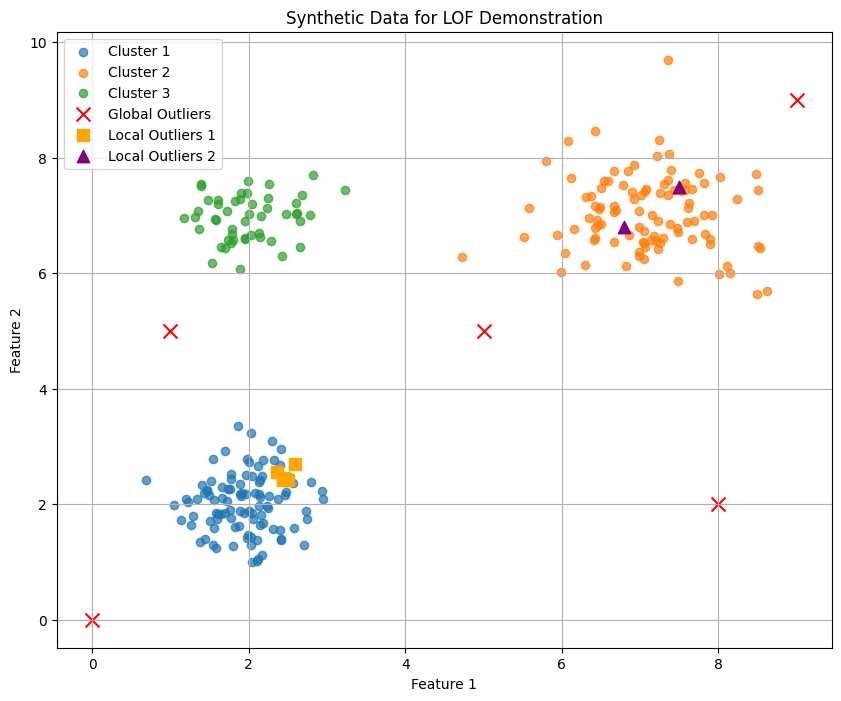

Total data points: 262


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import euclidean

np.random.seed(42)

# Generate normal data points (clusters)
cluster1 = np.random.normal(loc=[2, 2], scale=[0.5, 0.5], size=(100, 2))
cluster2 = np.random.normal(loc=[7, 7], scale=[0.7, 0.7], size=(100, 2))
cluster3 = np.random.normal(loc=[2, 7], scale=[0.4, 0.4], size=(50, 2))

# Generate some outliers
outliers = np.array([
    [1, 5], [8, 2], [5, 5], [0, 0], [9, 9] # Global outliers
])

# Add some local outliers within a denser region
local_outlier_1 = np.random.normal(loc=[2.5, 2.5], scale=[0.1, 0.1], size=(5, 2)) # Close to cluster 1 but slightly off
local_outlier_2 = np.array([[7.5, 7.5], [6.8, 6.8]]) # Near cluster 2

# Combine all data points
X = np.vstack([cluster1, cluster2, cluster3, outliers, local_outlier_1, local_outlier_2])

# Plot the synthetic data
plt.figure(figsize=(10, 8))
plt.scatter(cluster1[:, 0], cluster1[:, 1], label='Cluster 1', alpha=0.7)
plt.scatter(cluster2[:, 0], cluster2[:, 1], label='Cluster 2', alpha=0.7)
plt.scatter(cluster3[:, 0], cluster3[:, 1], label='Cluster 3', alpha=0.7)
plt.scatter(outliers[:, 0], outliers[:, 1], color='red', marker='x', s=100, label='Global Outliers')
plt.scatter(local_outlier_1[:, 0], local_outlier_1[:, 1], color='orange', marker='s', s=80, label='Local Outliers 1')
plt.scatter(local_outlier_2[:, 0], local_outlier_2[:, 1], color='purple', marker='^', s=80, label='Local Outliers 2')

plt.title('Synthetic Data for LOF Demonstration')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

print(f"Total data points: {len(X)}")

## 6. Step 1: Define the $k$-Neighborhood and $k$-distance

We need to choose a value for $k$, which represents the number of neighbors to consider. For each point, we find its $k$-distance, which is the distance to its $k$-th nearest neighbor. All points within this radius form the $k$-neighborhood.

In [7]:
# Choose k (min_samples in LOF terms, usually between 20-50 for general use, but smaller for synthetic data)
k = 5
nbrs = NearestNeighbors(n_neighbors=k + 1, algorithm='auto').fit(X)
distances, indices = nbrs.kneighbors(X)

k_distances = distances[:, k]


k_neighborhoods = {}
for i in range(len(X)):

    neighbors_indices = []
    for j in range(1, k + 1):
        if distances[i, j] <= k_distances[i]:
            neighbors_indices.append(indices[i, j])
    k_neighborhoods[i] = neighbors_indices

print(f"k-distance for point 0: {k_distances[0]:.4f}")
print(f"k-distance for point {len(X)-1}: {k_distances[len(X)-1]:.4f}")
print(f"Number of neighbors for point 0 in N_k(p): {len(k_neighborhoods[0])}")

k-distance for point 0: 0.2180
k-distance for point 261: 0.2928
Number of neighbors for point 0 in N_k(p): 5


## 7. Step 2: Calculate Reachability Distance

The reachability distance helps smooth out the density calculations by considering the $k$-distance of the neighbor. If a point $p$ is very close to its neighbor $o$, the reachability distance is $o$'s $k$-distance; otherwise, it's the actual Euclidean distance between $p$ and $o$.

In [8]:
def calculate_reach_dist(p_idx, o_idx, k_distances_array, data_points):
    actual_distance = euclidean(data_points[p_idx], data_points[o_idx])
    return max(k_distances_array[o_idx], actual_distance)

# Calculate reachability distances for all points to their neighbors
reach_distances = np.zeros_like(distances)
for i in range(len(X)):
    for j in range(1, k + 1): # Iterate through the actual neighbors (excluding self)
        neighbor_idx = indices[i, j]
        reach_distances[i, j] = calculate_reach_dist(i, neighbor_idx, k_distances, X)

# Example: Reachability distance from point 0 to its first neighbor
# (its first actual neighbor is at indices[0, 1])
example_p_idx = 0
example_o_idx = indices[example_p_idx, 1] # First neighbor of point 0

print(f"Actual distance from point {example_p_idx} to neighbor {example_o_idx}: {euclidean(X[example_p_idx], X[example_o_idx]):.4f}")
print(f"k-distance of neighbor {example_o_idx}: {k_distances[example_o_idx]:.4f}")
print(f"Reachability distance from point {example_p_idx} to neighbor {example_o_idx}: {reach_distances[example_p_idx, 1]:.4f}")

Actual distance from point 0 to neighbor 93: 0.0348
k-distance of neighbor 93: 0.1865
Reachability distance from point 0 to neighbor 93: 0.1865


## 8. Step 3: Compute Local Reachability Density (LRD)

LRD is the inverse of the average reachability distance from a point's neighbors. A high LRD means the point is in a dense area, while a low LRD indicates a sparse area.

In [9]:
def calculate_lrd(p_idx, k_neighborhoods_dict, k_distances_array, data_points):
    neighbors_indices = k_neighborhoods_dict[p_idx]
    if not neighbors_indices:
        return float('inf') # Or a very large number if no neighbors found (shouldn't happen with k_neighbors >= 1)

    sum_reach_dists = 0
    for o_idx in neighbors_indices:
        sum_reach_dists += calculate_reach_dist(p_idx, o_idx, k_distances_array, data_points)

    # The original LOF formula uses |Nk(p)| as the numerator, which is the number of neighbors.
    # This definition of LRD can be tricky because `k_neighborhoods[p_idx]` might contain fewer than k points
    # if some points are exactly on the k-distance boundary.
    # The standard implementation often uses k as the numerator, or the actual number of neighbors within the k-distance.
    # We'll stick to the definition provided in the markdown for consistency, which is |Nk(p)|.

    # Handle sum_reach_dists being 0 to avoid division by zero
    if sum_reach_dists == 0:
        return float('inf') # Infinite density if all reach-dists are 0 (points are identical)

    return len(neighbors_indices) / sum_reach_dists

lrds = np.array([calculate_lrd(i, k_neighborhoods, k_distances, X) for i in range(len(X))])

# Display LRD for a few sample points
print(f"LRD for point 0 (normal): {lrds[0]:.4f}")
print(f"LRD for point {len(X)-1} (local outlier): {lrds[len(X)-1]:.4f}")
print(f"Mean LRD: {np.mean(lrds):.4f}")

LRD for point 0 (normal): 5.4431
LRD for point 261 (local outlier): 3.6628
Mean LRD: 3.9510


## 9. Step 4: Compute the Final LOF Score

The LOF score compares a point's LRD to the LRDs of its neighbors. A score close to 1 means the point is similar to its neighbors in terms of density. A score significantly greater than 1 indicates an outlier, as its LRD is much lower than its neighbors' LRDs.

In [10]:
def calculate_lof(p_idx, k_neighborhoods_dict, lrd_array):
    neighbors_indices = k_neighborhoods_dict[p_idx]
    if not neighbors_indices or lrd_array[p_idx] == 0: # Avoid division by zero
        return float('inf')

    sum_ratios = 0
    for o_idx in neighbors_indices:
        # Handle case where neighbor's LRD is zero, indicating very high local density
        # If a neighbor has LRD=0 (meaning its sum_reach_dists was inf), it implies an anomaly
        # or identical points. For LOF, if lrd_array[o_idx] is very high (inf), it means 1/inf is 0.
        # If lrd_array[o_idx] is 0, then we have a problem. Assuming lrd_array[o_idx] is never 0 from calc_lrd.
        if lrd_array[o_idx] == 0:
            # This scenario indicates an issue or a very specific edge case.
            # For practical purposes, if LRD is 0, consider it extremely dense compared to p
            # or treat as an undefined ratio leading to inf anomaly score for p.
            # For now, let's assume valid LRDs > 0.
            sum_ratios += 0 # Or handle more explicitly
        else:
            sum_ratios += lrd_array[o_idx] / lrd_array[p_idx]

    return sum_ratios / len(neighbors_indices)

lof_scores = np.array([calculate_lof(i, k_neighborhoods, lrds) for i in range(len(X))])

# Display LOF scores for a few sample points
print(f"LOF score for point 0 (normal): {lof_scores[0]:.4f}")
print(f"LOF score for global outlier (e.g., index {len(cluster1)+len(cluster2)+len(cluster3)}): {lof_scores[len(cluster1)+len(cluster2)+len(cluster3)]:.4f}")
print(f"LOF score for local outlier (e.g., index {len(cluster1)+len(cluster2)+len(cluster3)+len(outliers)}): {lof_scores[len(cluster1)+len(cluster2)+len(cluster3)+len(outliers)]:.4f}")

# Sort and display top 10 highest LOF scores
sorted_lof_indices = np.argsort(lof_scores)[::-1]
print("\nTop 10 LOF scores:")
for i in range(10):
    idx = sorted_lof_indices[i]
    print(f"Point {idx}: LOF={lof_scores[idx]:.4f}, Coordinates={X[idx]}")

LOF score for point 0 (normal): 0.9854
LOF score for global outlier (e.g., index 250): 5.8448
LOF score for local outlier (e.g., index 255): 1.2765

Top 10 LOF scores:
Point 253: LOF=6.4098, Coordinates=[0. 0.]
Point 251: LOF=6.0428, Coordinates=[8. 2.]
Point 250: LOF=5.8448, Coordinates=[1. 5.]
Point 254: LOF=3.0955, Coordinates=[9. 9.]
Point 37: LOF=2.7288, Coordinates=[0.69012745 2.41095125]
Point 104: LOF=2.5523, Coordinates=[7.36053338 9.69691204]
Point 252: LOF=2.4558, Coordinates=[5. 5.]
Point 111: LOF=2.1033, Coordinates=[7.48038213 5.87109889]
Point 239: LOF=2.0630, Coordinates=[3.23155232 7.44782996]
Point 235: LOF=2.0390, Coordinates=[1.88997932 6.07923153]


## 10. Visualize LOF Scores

Finally, let's visualize the data points colored by their LOF scores. Points with higher LOF scores (typically > 1.5 or 2, depending on the data) are considered outliers and will be colored differently.

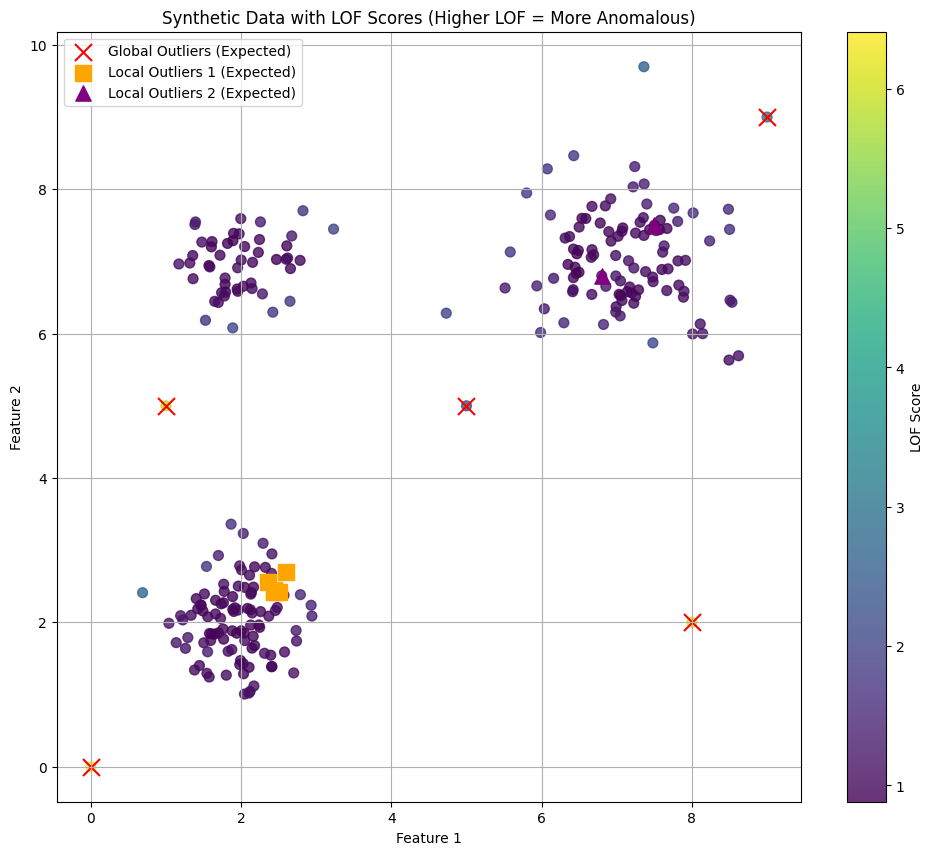

In [11]:
plt.figure(figsize=(12, 10))
scatter = plt.scatter(X[:, 0], X[:, 1], c=lof_scores, cmap='viridis', s=50, alpha=0.8)

# Add global outliers again for visual reference
plt.scatter(outliers[:, 0], outliers[:, 1], color='red', marker='x', s=150, label='Global Outliers (Expected)')
plt.scatter(local_outlier_1[:, 0], local_outlier_1[:, 1], color='orange', marker='s', s=120, label='Local Outliers 1 (Expected)')
plt.scatter(local_outlier_2[:, 0], local_outlier_2[:, 1], color='purple', marker='^', s=120, label='Local Outliers 2 (Expected)')

cbar = plt.colorbar(scatter)
cbar.set_label('LOF Score')

plt.title('Synthetic Data with LOF Scores (Higher LOF = More Anomalous)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()